# **Ring Resonator**
*Notebook for Implementation and Testing of Ring Resonator Simulation*


In [34]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ml imports
import torch
import torch.nn.functional as F


# import module
from nlse import *

In [35]:
"""-----Primary Parameters-----"""
# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 100               # Number of steps in z
dz = Lz / Nz            # Step size in z
Lt = 3                  # Temporal window size
Nt = 2048               # Number of temporal points
dt = Lt / Nt
N_modes = 100

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = -10           # anomalous GVD region
gamma_j = 0
gamma_k = 0

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

# define ring resonator parameters
R = 0.4
T = 1 - R
r_coeff = np.sqrt(R)
t_coeff = np.sqrt(T)

# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt)
hg_basis = get_hg_basis(N_modes, t, tau)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [36]:
"""-----Secondary Parameters-----"""
# input pulse parameters
amplitude = 0.32 # roughly that of weak soliton used in training

# loops in resonator
N_resonator = 10

In [37]:
def gaussian(t, tau, amplitude):
    """Generate a Gaussian pulse using PyTorch."""
    return amplitude * torch.exp(-(t ** 2) / (2 * tau ** 2))

weak_input = gaussian(t, tau, amplitude)
dummy_input = torch.zeros_like(t)

### **Simulation Code**
For now we simulate using XPM but with a dummy strong pulse

In [38]:
# propagation function for pulse in resonator
def propagate_L(A0_j, A0_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt, strangsplitting = True): # A_j = weak, A_k = strong
    """Propagate Weak (j) and Strong (k) Pulse Distance L (in Ring Resonator)"""
    A_j = A0_j.clone()
    A_k = A0_k.clone()
    Nt = len(A_j)
    dt = Lt / Nt
    A_j_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_j.device)
    A_k_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_k.device)
    A_j_evolution[:, 0] = A0_j  # Set first column of A_j_evolution to be the initial pulse
    A_k_evolution[:, 0] = A0_k  # Set first column of A_k_evolution to be the initial pulse

    for i in range(Nz):
        # we want to preserve symmetry in both of the waves - always use the wave at i-th step to go to i+1-th step ? is this that important?
        _A_j = A_j.clone() 
        _A_k = A_k.clone()
        
        if strangsplitting:
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j = nonlinear_operator_xpm(gamma_j, A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k = nonlinear_operator_xpm(gamma_k, A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            
            A_j_evolution[:, i+1] = A_j
            A_k_evolution[:, i+1] = A_k
            
        else:
            # for weak wave j
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j_evolution[:, i+1] = A_j
            
            # for strong wave k
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k_evolution[:, i+1] = A_k
            
    return A_j_evolution, A_k_evolution

# beam splitter function 
# *only for weak pulse for now
def beam_splitter(a, d, r, t): 
    """Beam Splitter"""
    '''a - pulse from waveguide, d - pulse from resonator'''
    b = t*a + r*d # into resonator
    c = r*a + t*d # out of resonator
    return b, c

### **Run Simulation**

In [39]:
"""-----Simulation Setup-----"""
resonator_energy = []
pulse_snaps = [] # stores pulse amplitudes

In [40]:
"""-----Simulation-----"""
# input into resonator is what gets transmitted
A_j = weak_input * t_coeff
A_k = dummy_input * t_coeff

resonator_energy.append(get_energy(A_j, dt))
pulse_snaps.append(A_j.numpy())

# simulate resonator
for i in tqdm(range(N_resonator), desc="Resonator Loop"):
    # propagate L in resonator
    A_j_ev, _ = propagate_L(A_j, A_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    A_j = A_j_ev[:, -1]
    
    # beam splitter
    A_j, _ = beam_splitter(weak_input, A_j, r_coeff, t_coeff)
    
    # save energy and pulse
    resonator_energy.append(get_energy(A_j, dt))
    pulse_snaps.append(A_j.numpy())

Resonator Loop: 100%|██████████| 10/10 [00:02<00:00,  3.45it/s]


### **Analytical Solution**

In [41]:
# variables for analytical solution
analytical_energy = []
analytical_pulse_snaps = []


for n in range(1, N_resonator+2):
    # get analytical pulse
    new_pulse = t_coeff * weak_input * (1-r_coeff**n)/(1-r_coeff)
    analytical_pulse_snaps.append(new_pulse.numpy())
    analytical_energy.append(get_energy(new_pulse, dt))

### **Plotting**

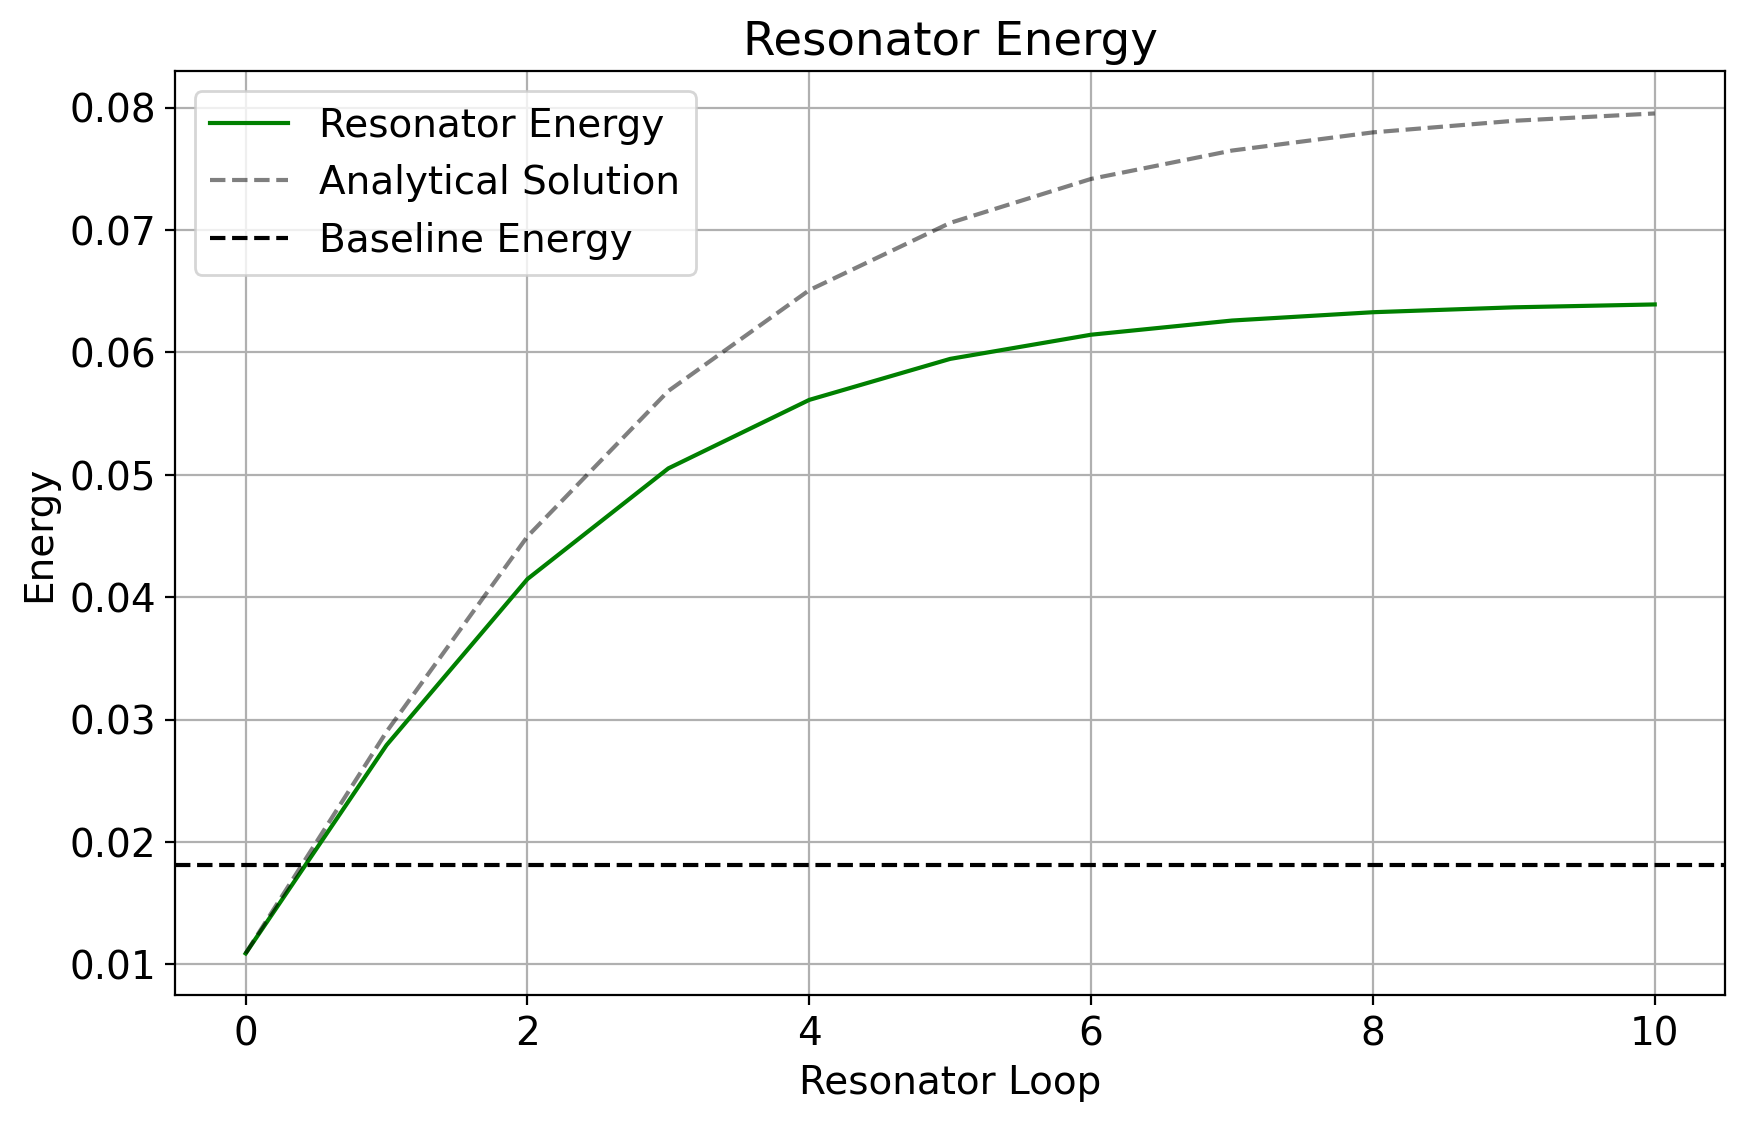

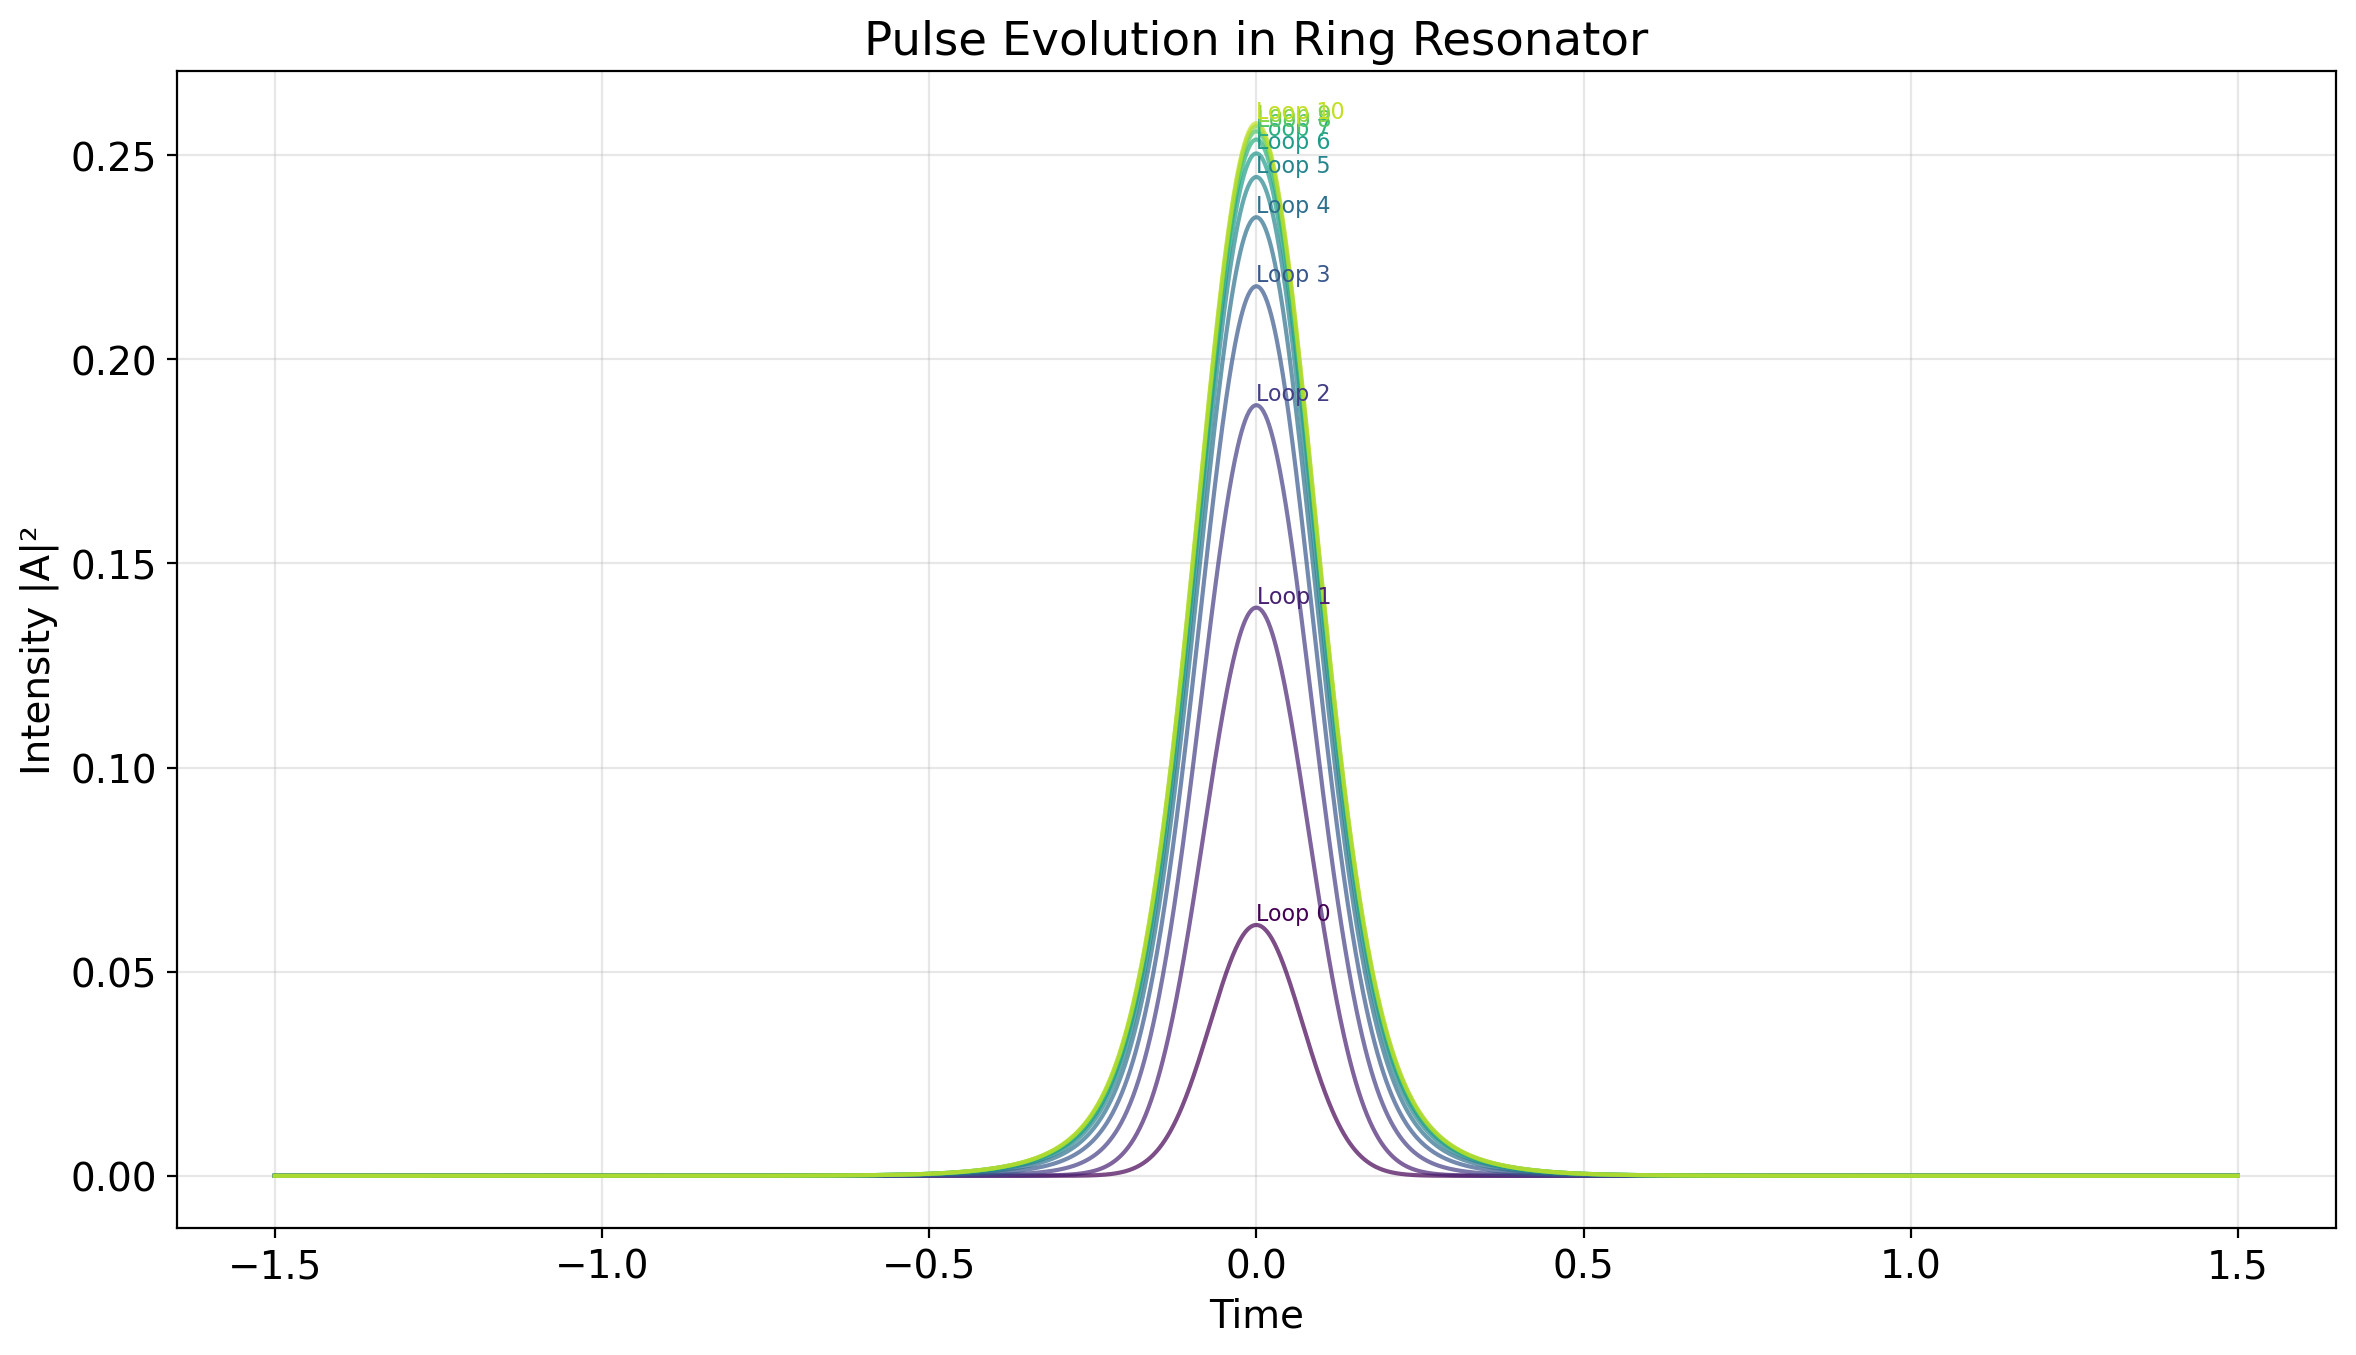

In [42]:
"""-----Plotting-----"""
baseline_energy = get_energy(weak_input, dt)
fig = plt.figure(figsize=(10, 6), dpi=200)
plt.plot(resonator_energy, label="Resonator Energy", color="g")
plt.plot(analytical_energy, label="Analytical Solution", linestyle="--", color="k", alpha=0.5)
plt.axhline(baseline_energy, color="k", linestyle="--", label="Baseline Energy")
plt.legend()
plt.xlabel("Resonator Loop")
plt.ylabel("Energy")
plt.title("Resonator Energy")
plt.grid(True)
plt.show()


fig = plt.figure(figsize=(12, 7), dpi=200)
# Create colormap for iterated colors
cmap = plt.cm.viridis  # or 'plasma', 'coolwarm', 'jet', etc.
colors = [cmap(i / len(pulse_snaps)) for i in range(len(pulse_snaps))]
# Plot each pulse snapshot
for i, pulse in enumerate(pulse_snaps):
    intensity = np.abs(pulse)**2
    line, = plt.plot(t.cpu().numpy(), intensity, color=colors[i], alpha=0.7, linewidth=1.5)
    
    # Add text label at the peak of each pulse
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    max_t = t.cpu().numpy()[max_idx]
    
    # Offset text slightly to avoid overlap
    plt.text(max_t, max_val, f'Loop {i}', 
             fontsize=8, 
             ha='left', 
             va='bottom',
             color=colors[i])

plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Pulse Evolution in Ring Resonator")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **Ring Resonator with Strong Pulse**
In the following code we also incorporate propagation of $N$ strong pulses

In [43]:
"""-----Pulse Setup-----"""
# strong input pulses
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    # calculate secondary parameters
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    # Define strong pulse waveform
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    return Ain_k
strong_input = strong_soliton(t, beta2_k, gamma_k, tau)
A_k_stack = torch.stack([strong_input for _ in range(N_resonator)]) # (N_resonator, Nt)

ZeroDivisionError: float division by zero

In [ ]:
"""-----Simulation Setup-----"""
resonator_energy = []
pulse_snaps = []

In [ ]:
"""-----Simulation-----"""
# input into resonator is what gets transmitted
A_j = weak_input * t_coeff

resonator_energy.append(get_energy(A_j, dt))
pulse_snaps.append(A_j.numpy())

# simulate resonator
for i in tqdm(range(N_resonator), desc="Resonator Loop"):
    # propagate L in resonator
    A_j_ev, _ = propagate_L(A_j, A_k_stack[i]*t_coeff, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    A_j = A_j_ev[:, -1]
    
    # beam splitter
    A_j, _ = beam_splitter(weak_input, A_j, r_coeff, t_coeff)
    
    # save energy
    resonator_energy.append(get_energy(A_j, dt))
    pulse_snaps.append(A_j.numpy())

Resonator Loop: 100%|██████████| 10/10 [00:02<00:00,  4.04it/s]


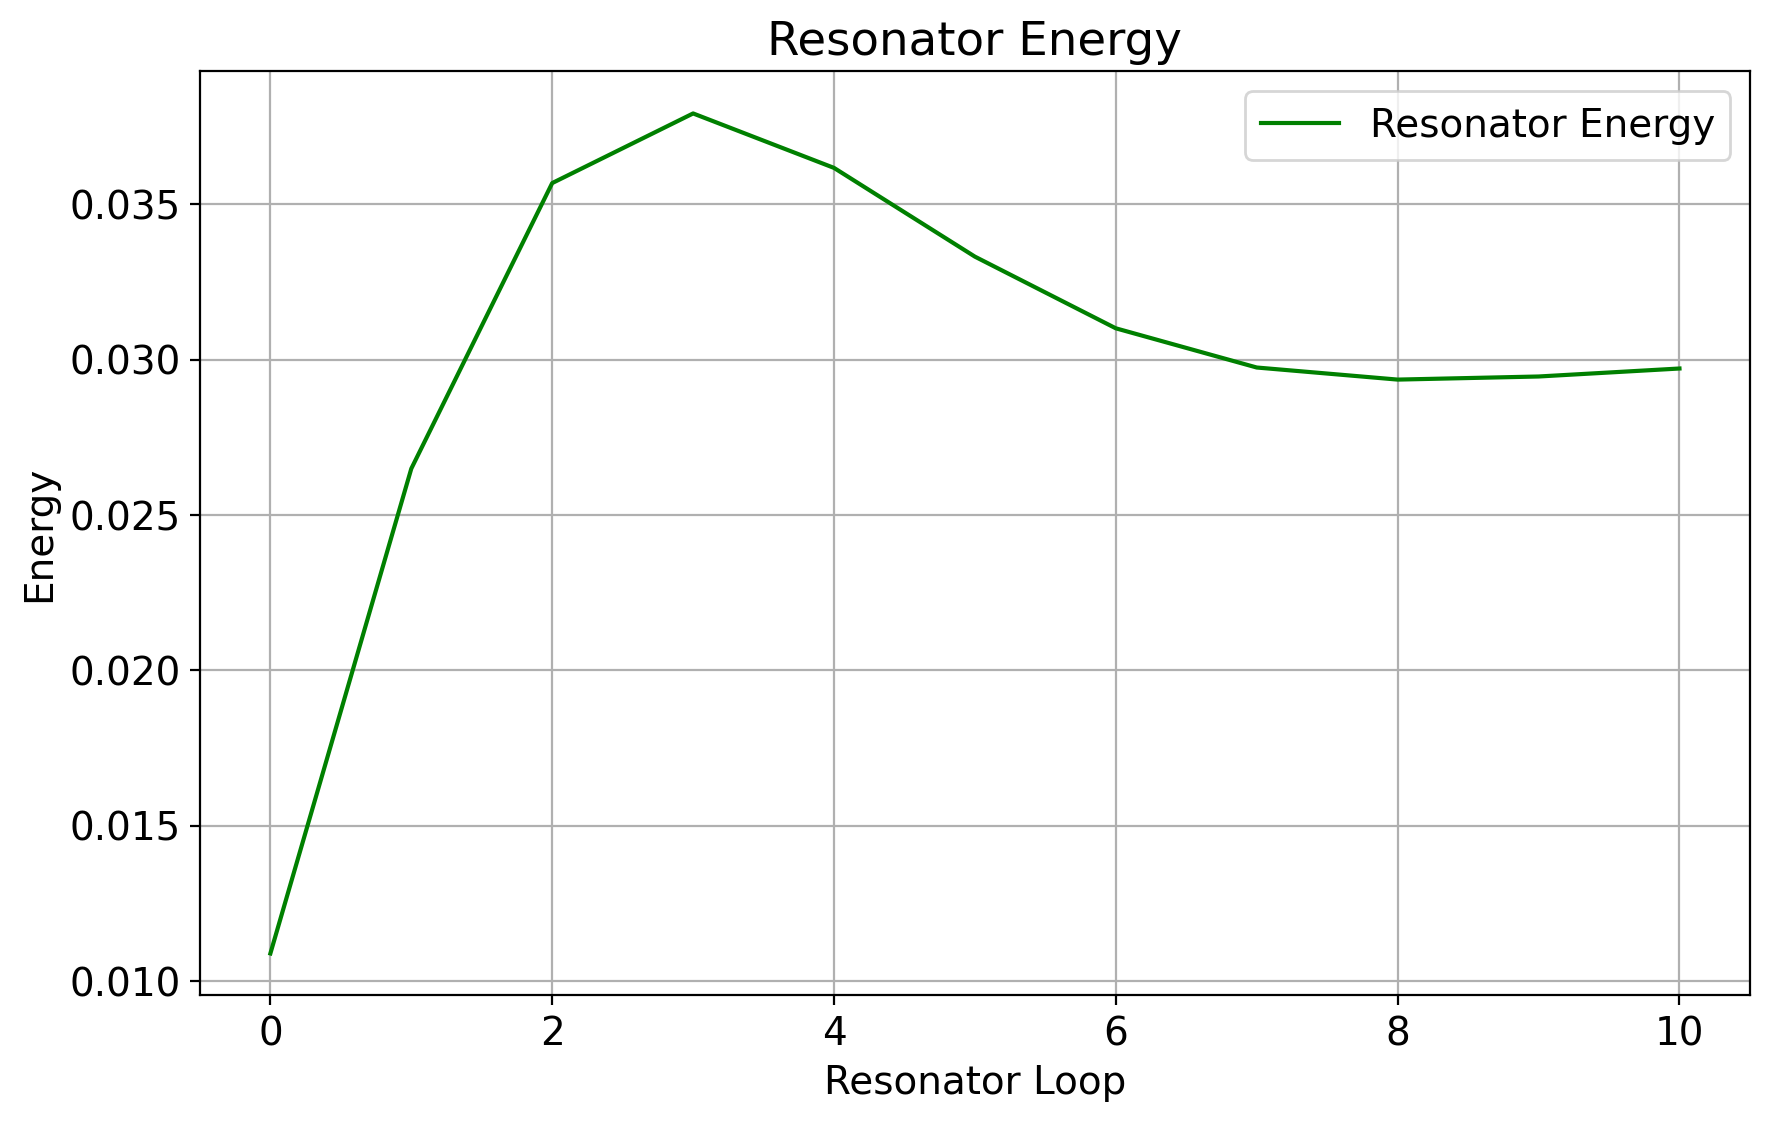

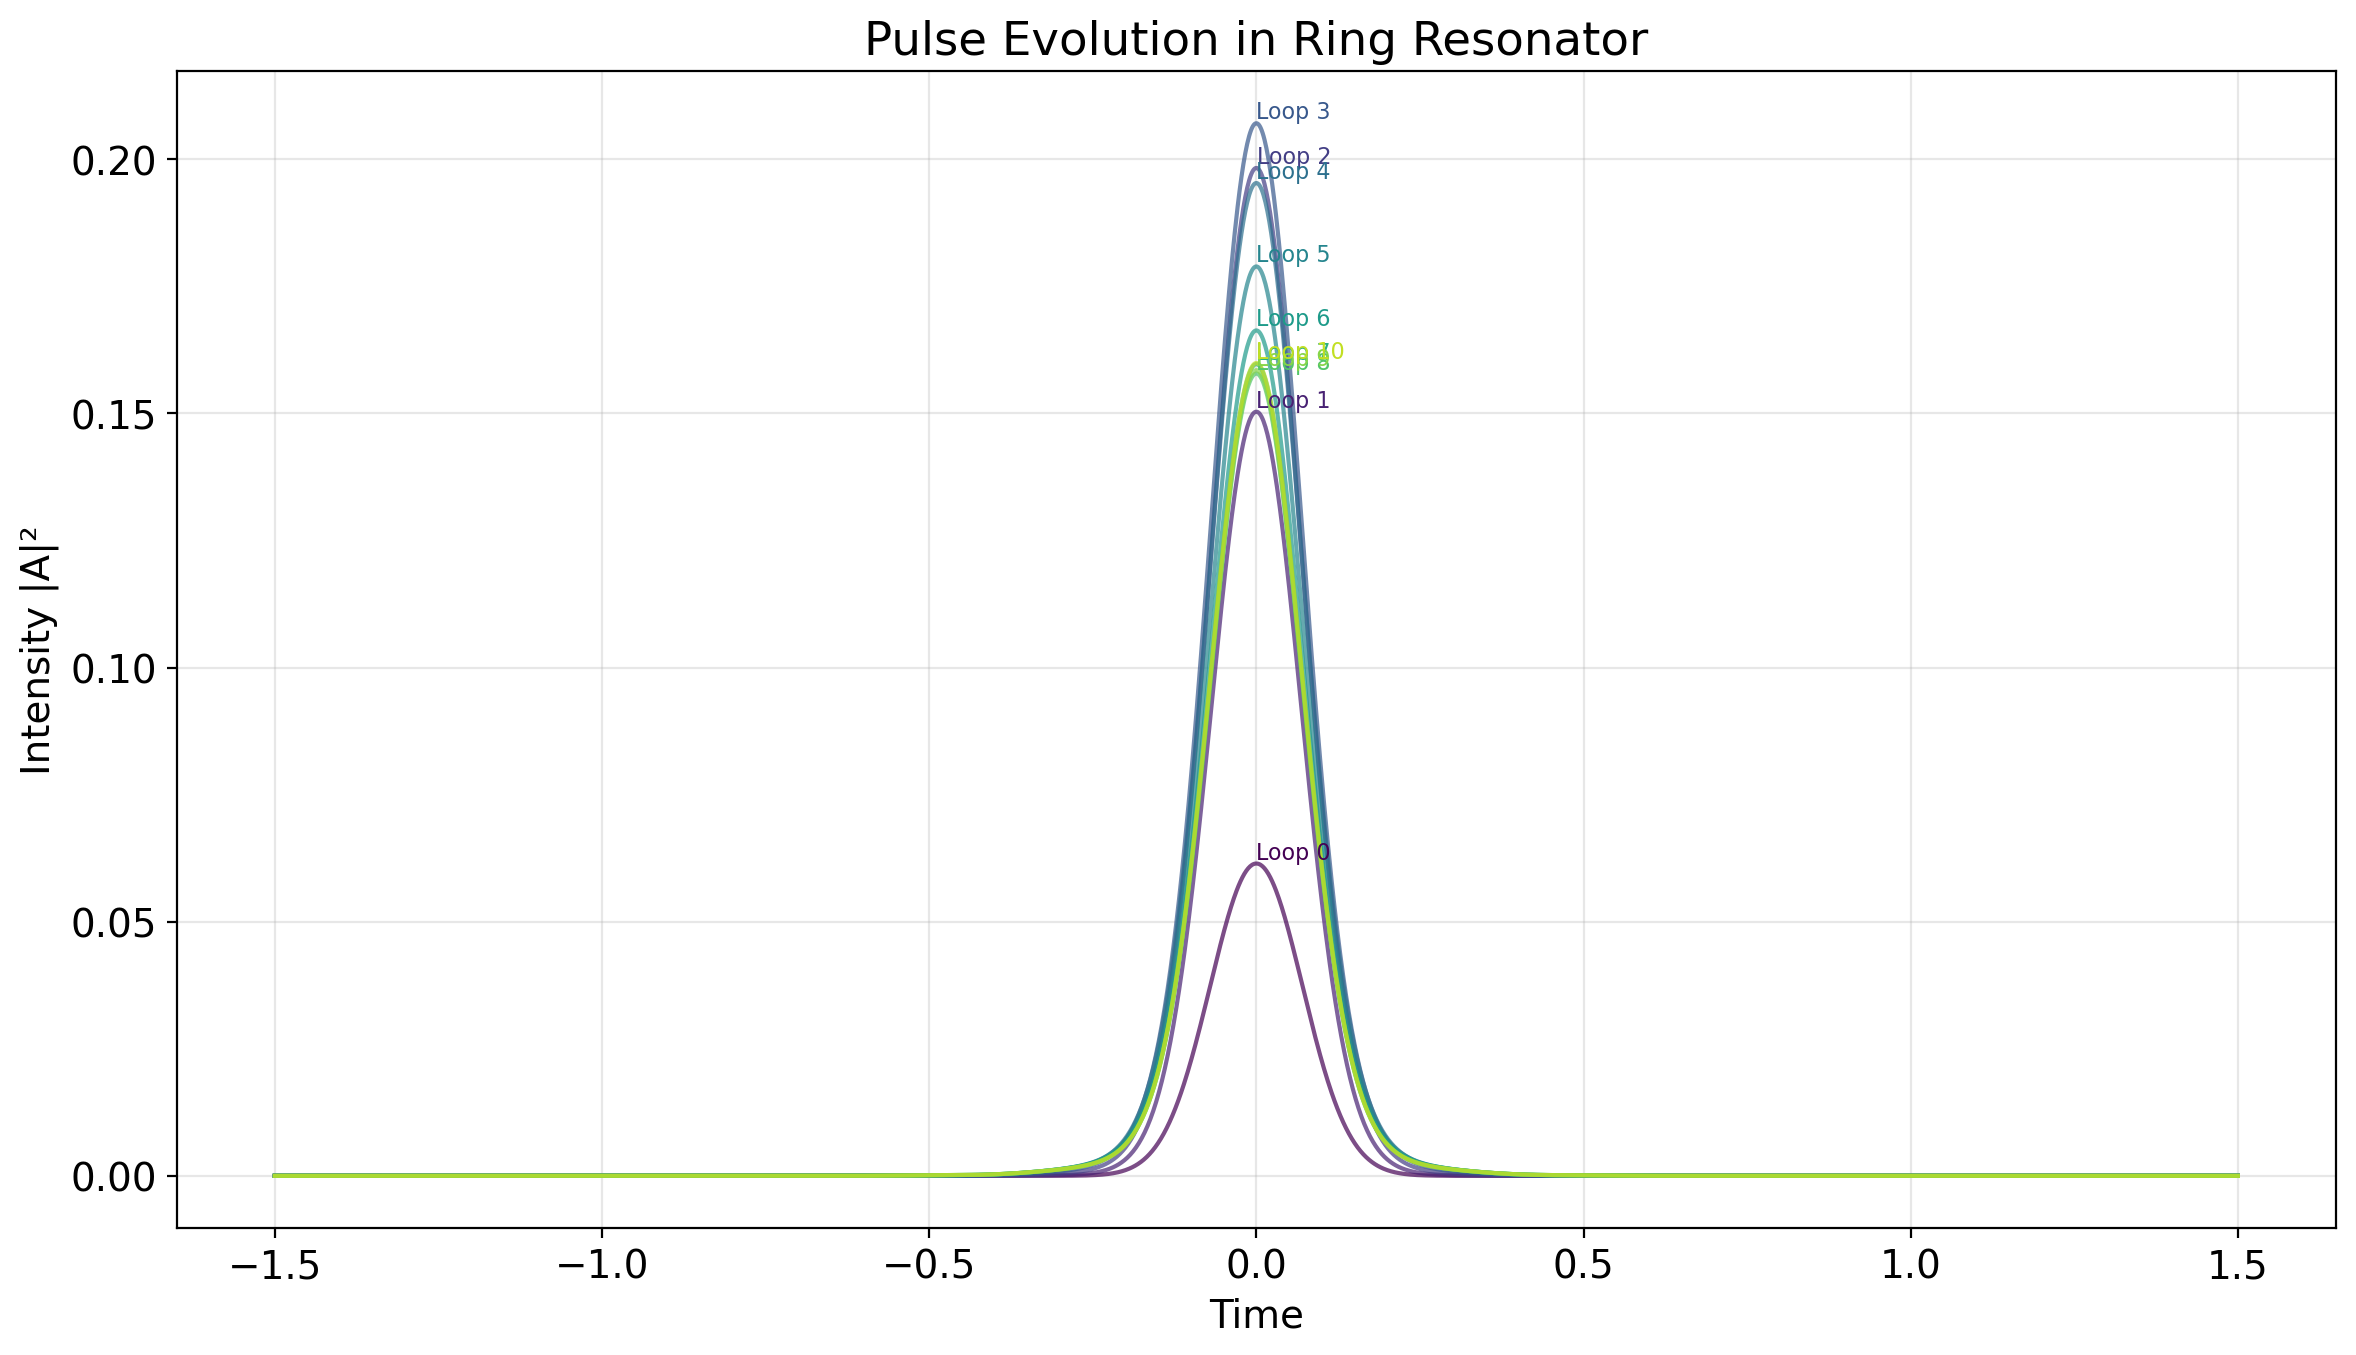

In [ ]:
"""-----Plotting-----"""
fig = plt.figure(figsize=(10, 6), dpi=200)
plt.plot(resonator_energy, label="Resonator Energy", color="g")
plt.legend()
plt.xlabel("Resonator Loop")
plt.ylabel("Energy")
plt.title("Resonator Energy")
plt.grid(True)
plt.show()


fig = plt.figure(figsize=(12, 7), dpi=200)
# Create colormap for iterated colors
cmap = plt.cm.viridis  # or 'plasma', 'coolwarm', 'jet', etc.
colors = [cmap(i / len(pulse_snaps)) for i in range(len(pulse_snaps))]
# Plot each pulse snapshot
for i, pulse in enumerate(pulse_snaps):
    intensity = np.abs(pulse)**2
    line, = plt.plot(t.cpu().numpy(), intensity, color=colors[i], alpha=0.7, linewidth=1.5)
    
    # Add text label at the peak of each pulse
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    max_t = t.cpu().numpy()[max_idx]
    
    # Offset text slightly to avoid overlap
    plt.text(max_t, max_val, f'Loop {i}', 
             fontsize=8, 
             ha='left', 
             va='bottom',
             color=colors[i])

plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Pulse Evolution in Ring Resonator")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Ring Resonator Training: Scaled Amplitude**

In [ ]:
"""-----Training Parameters-----"""
# define weak pulse mode
B = 16
mode = 6

# define hyperparameters
N_train = 10
lr = 1e-3

# get hg_basis
hg_basis = get_hg_basis(N_modes, t, tau) #*
hg_basis_B = hg_basis[:B]

# define initial input pulse shape
strong_input = strong_soliton(t, beta2_k, gamma_k, tau)
strong_input_hg = time_to_hg(strong_input, hg_basis, dt)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [ ]:
"""-----Training Setup-----"""
# define storage
losses = []

# define training parameters
A_k_hg = torch.nn.Parameter(strong_input_hg.clone().detach().requires_grad_(True))
alphas = torch.nn.Parameter(torch.ones(N_resonator).clone().detach().requires_grad_(True))

# define trainable pulse
A_j_input = hg_basis[mode]

# define loss function
y_hg = torch.zeros(B)
y_hg[mode] = 1
def loss_function(final_j):
    """Fidelity loss on HG coefficients (phase-aware, no normalization)"""
    final_j_hg = time_to_hg(final_j, hg_basis_B, dt)  # shape: (B)
    
    # Fidelity loss (phase-aware)
    dot_products = torch.sum(final_j_hg.conj() * y_hg)  # sum along rows
    fidelity_avg = torch.abs(dot_products)**2
    fid_loss = -fidelity_avg  # negative because we want to maximize fidelity
    
    return fid_loss

def forward(A_k_hg, alphas):
    # get time domain representation of strong pulse
    A_k = hg_to_time(A_k_hg, hg_basis)
    
    # define strong input sequence
    A_k_stack = torch.stack([A_k*alphas[i] for i in range(N_resonator)]) # (N_resonator, Nt)
    
    # run simulation
    A_j = A_j_input * t_coeff
    for i in range(N_resonator):
        # propagate L in resonator
        A_j_ev, _ = propagate_L(A_j, A_k_stack[i], dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt) #? assume pure entry of strong pulse (?)
        A_j = A_j_ev[:, -1]
        
        # beam splitter
        A_j, _ = beam_splitter(weak_input, A_j, r_coeff, t_coeff)
        
    return A_j*t_coeff
    
# initialize optimizer
optimizer = torch.optim.Adam([A_k, alphas], lr=lr)
    

In [ ]:
"""-----Training-----"""
# run training
for i in tqdm(range(N_train), desc="Training"):
    optimizer.zero_grad()
    A_j_out = forward(A_k_hg, alphas)
    loss = loss_function(A_j_out)
    loss.backward()
    optimizer.step()


    losses.append(loss.item())




Training:   0%|          | 0/10 [00:08<?, ?it/s]


KeyboardInterrupt: 

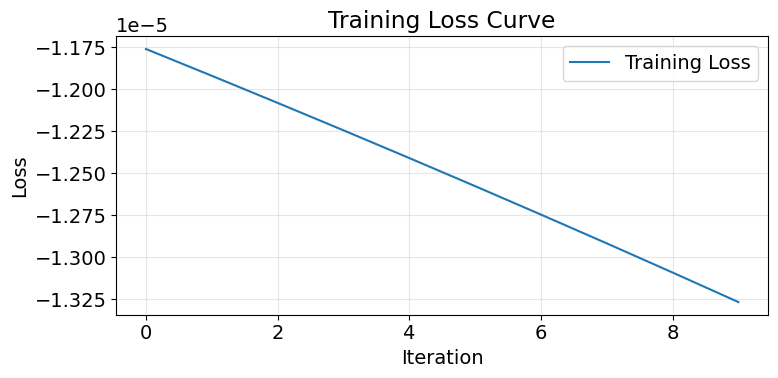

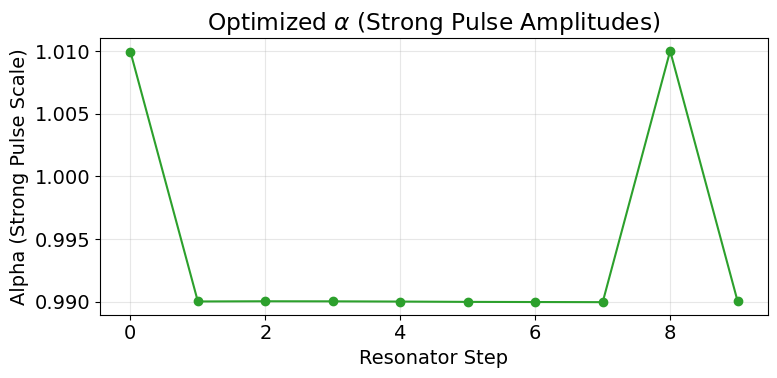

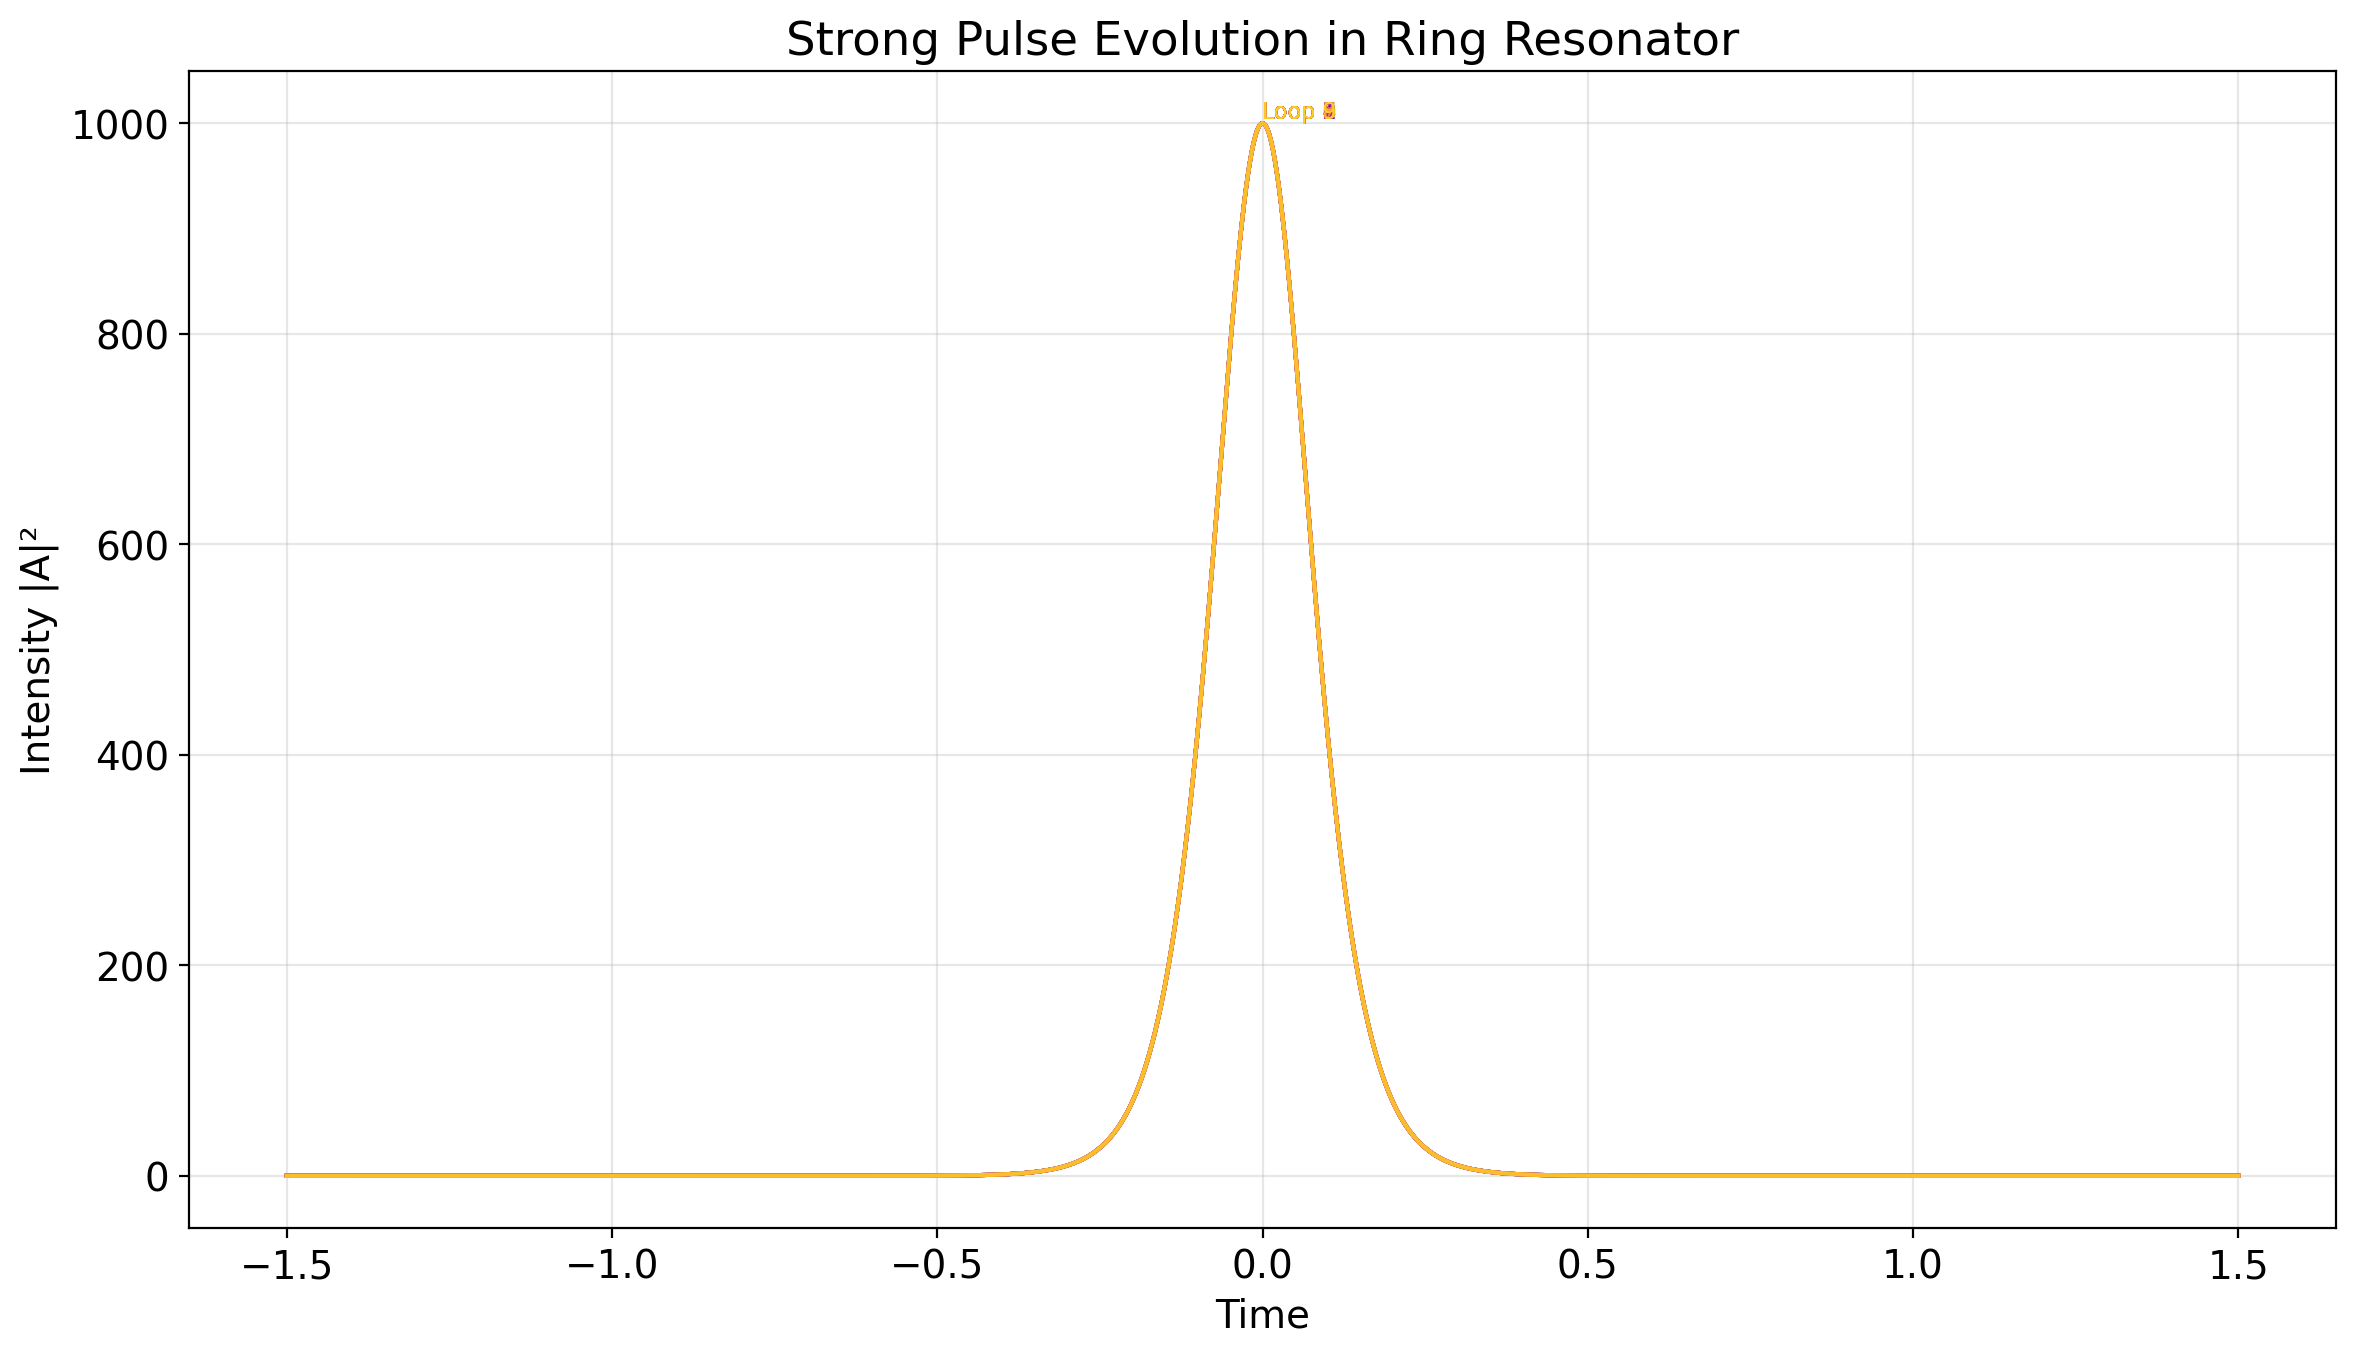

In [ ]:
"""-----Plotting-----"""
# Plot loss curve
plt.figure(figsize=(8,4))
plt.plot(losses, label="Training Loss", color='tab:blue')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot found alphas
plt.figure(figsize=(8, 4))
plt.plot(alphas.detach().cpu().numpy(), marker='o', linestyle='-', color='tab:green')
plt.xlabel("Resonator Step")
plt.ylabel("Alpha (Strong Pulse Scale)")
plt.title("Optimized $\u03B1$ (Strong Pulse Amplitudes)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot strong pulse evolution (intensity as a function of time for each resonator loop)
fig = plt.figure(figsize=(12, 7), dpi=200)
# Create colormap for iterated colors
cmap = plt.cm.plasma
colors = [cmap(i / len(A_k_stack)) for i in range(len(A_k_stack))]
# Plot each pulse snapshot (saved in A_k_stack)
for i, pulse in enumerate(A_k_stack):
    if isinstance(pulse, torch.Tensor):
        pulse_np = pulse.detach().cpu().numpy()
    else:
        pulse_np = pulse
    intensity = np.abs(pulse_np)**2
    line, = plt.plot(t.cpu().numpy(), intensity, color=colors[i], alpha=0.7, linewidth=1.5)
    # Add text label at the peak of each pulse
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    max_t = t.cpu().numpy()[max_idx]
    plt.text(max_t, max_val, f'Loop {i}', 
             fontsize=8, 
             ha='left', 
             va='bottom',
             color=colors[i])

plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Strong Pulse Evolution in Ring Resonator")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Ring Resonator Training: Arbitrary Strong Pulses**

In [ ]:
"""-----Training Parameters-----"""
# define weak pulse mode
B = 16
mode = 6

# define hyperparameters
N_train = 10
lr = 1e-3

# get hg_basis
hg_basis = get_hg_basis(N_modes, t, tau) #*
hg_basis_B = hg_basis[:B]

# define initial input pulse shape
strong_input = strong_soliton(t, beta2_k, gamma_k, tau)
strong_input_hg = time_to_hg(strong_input, hg_basis, dt)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [ ]:
"""-----Training Setup-----"""
# define storage
losses = []

# define training parameters - each resonator step has its own independent strong pulse in HG basis
A_k_hg_stack = torch.nn.Parameter(
    torch.stack([strong_input_hg.clone() for _ in range(N_resonator)]).detach().requires_grad_(True)
)  # (N_resonator, N_modes)

# define trainable pulse
A_j_input = hg_basis[mode]

# define loss function
y_hg = torch.zeros(B)
y_hg[mode] = 1
def loss_function(final_j):
    """Fidelity loss on HG coefficients (phase-aware, no normalization)"""
    final_j_hg = time_to_hg(final_j, hg_basis_B, dt)  # shape: (B)
    
    # Fidelity loss (phase-aware)
    dot_products = torch.sum(final_j_hg.conj() * y_hg)  # sum along rows
    fidelity_avg = torch.abs(dot_products)**2
    fid_loss = -fidelity_avg  # negative because we want to maximize fidelity
    
    return fid_loss

def forward(A_k_hg_stack):
    # get time domain representation of each strong pulse independently
    A_k_stack = torch.stack([hg_to_time(A_k_hg_stack[i], hg_basis) for i in range(N_resonator)])  # (N_resonator, Nt)
    
    # run simulation
    A_j = A_j_input * t_coeff
    for i in range(N_resonator):
        # propagate L in resonator
        A_j_ev, _ = propagate_L(A_j, A_k_stack[i], dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
        A_j = A_j_ev[:, -1]
        
        # beam splitter
        A_j, _ = beam_splitter(weak_input, A_j, r_coeff, t_coeff)
        
    return A_j*t_coeff
    
# initialize optimizer
optimizer = torch.optim.Adam([A_k_hg_stack], lr=lr)

In [ ]:
"""-----Training-----"""
# run training
for i in tqdm(range(N_train), desc="Training"):
    optimizer.zero_grad()
    A_j_out = forward(A_k_hg_stack)
    loss = loss_function(A_j_out)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

Training: 100%|██████████| 10/10 [01:19<00:00,  7.91s/it]


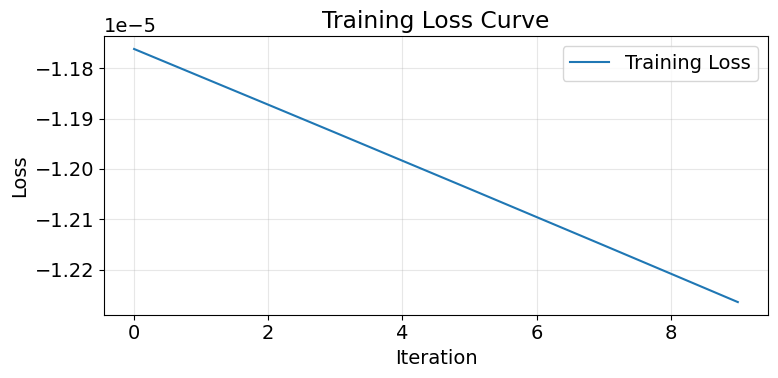

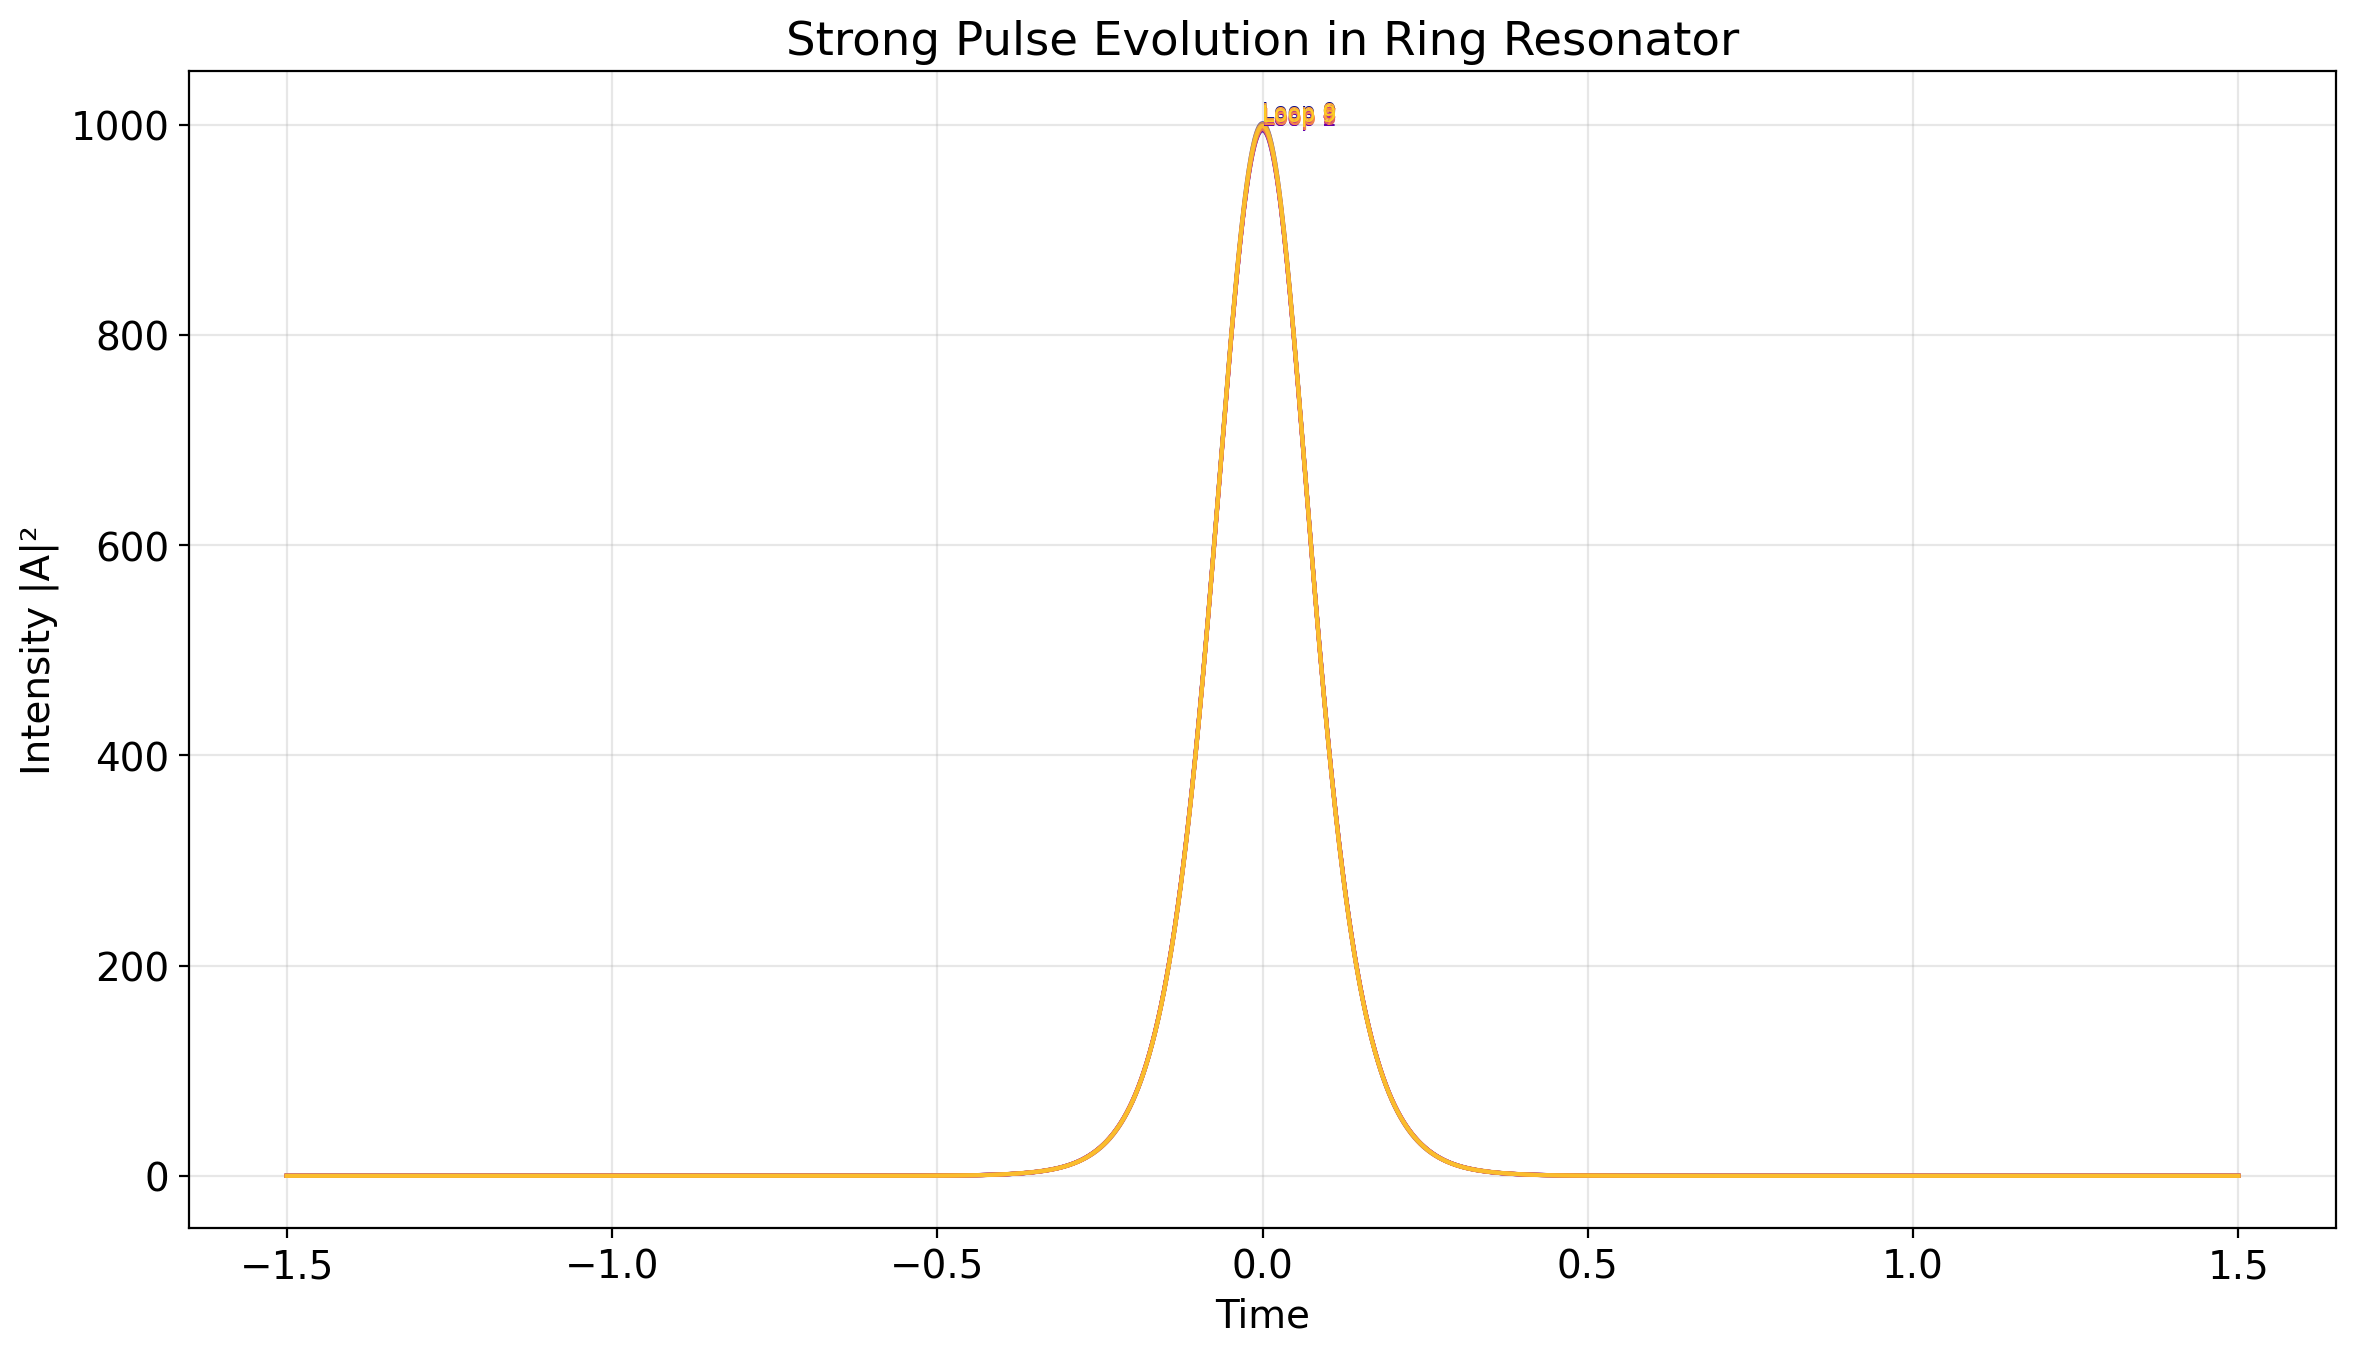

In [ ]:
# Plot loss curve
plt.figure(figsize=(8,4))
plt.plot(losses, label="Training Loss", color='tab:blue')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot strong pulse evolution (intensity as a function of time for each resonator loop)
with torch.no_grad():
    A_k_stack = torch.stack([hg_to_time(A_k_hg_stack[i], hg_basis) for i in range(N_resonator)])

fig = plt.figure(figsize=(12, 7), dpi=200)
# Create colormap for iterated colors
cmap = plt.cm.plasma
colors = [cmap(i / len(A_k_stack)) for i in range(len(A_k_stack))]
# Plot each pulse snapshot (saved in A_k_stack)
for i, pulse in enumerate(A_k_stack):
    if isinstance(pulse, torch.Tensor):
        pulse_np = pulse.detach().cpu().numpy()
    else:
        pulse_np = pulse
    intensity = np.abs(pulse_np)**2
    line, = plt.plot(t.cpu().numpy(), intensity, color=colors[i], alpha=0.7, linewidth=1.5)
    # Add text label at the peak of each pulse
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    max_t = t.cpu().numpy()[max_idx]
    plt.text(max_t, max_val, f'Loop {i}', 
             fontsize=8, 
             ha='left', 
             va='bottom',
             color=colors[i])

plt.xlabel("Time")
plt.ylabel("Intensity |A|²")
plt.title("Strong Pulse Evolution in Ring Resonator")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()